# Simple 2D inversion test

The following is a toy example to illustrate how to use `pypcga`. It exposes the main useful features. The forward is simple static smoohting (non linear but with no time dependance) and is used both to produce a reference field from which observations will be sampled and the inversion.

- Import the required modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import covmats
import pypcga
from pypcga._utils import NDArrayFloat
import logging
import nested_grid_plotter as ngp

- Apply nice parameters for the plots

In [2]:
ngp.apply_nice_default_rc_params()

- Create some logging instances to illustrate how to use them in a complex workflow

In [3]:
# Create loggers
main_logger = logging.getLogger("main")
main_logger.setLevel(logging.INFO)
pcga_logger = logging.getLogger("PCGA")
pcga_logger.setLevel(logging.INFO)
main_logger.info("This is the main logger")
pcga_logger.info("This is the PCGA logger")

Let's use an example provided by `covmats`. Here, the prior covariance matrix, $\mathbf{C}_{\mathrm{prior}}$ is represented as a sparse factorization of its inverse $\mathbf{C}_{\mathrm{prior}}^{-1}$ with $\mathbf{LDL}^{\mathrm{T}} = \mathbf{PC}_{\mathrm{prior}}^{-1}\mathbf{P}^{\mathrm{T}}$. This is wrapped in the `covmats.CovViaSparsePrecisionCholesky` instance we create:

In [4]:
cov_prior = covmats.CovViaSparsePrecisionCholesky(
    covmats.load_precision_example_4225x_SCF()
)
cov_prior

<4225x4225 CovViaSparsePrecisionCholesky with dtype=float64>

The covariance matrix has shape (4225, 4225) , let's define a square domain (65, 65) and perform a non conditional simulation using our prior. We set a mean @ 50 and display it:

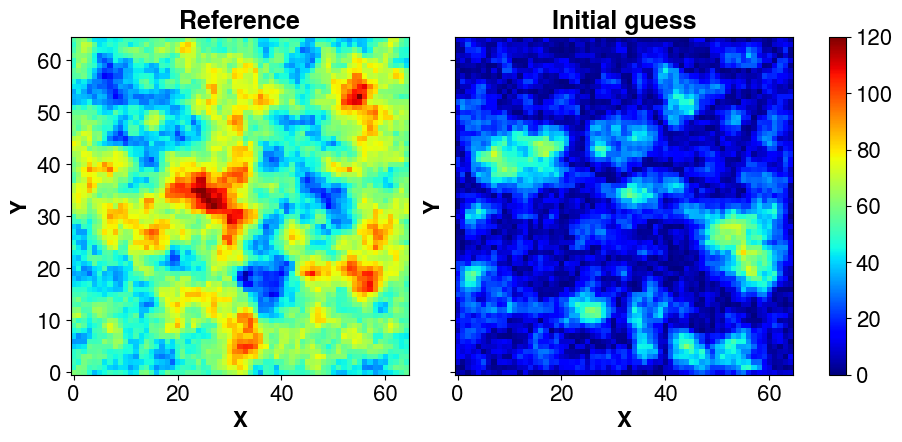

In [5]:
# Domain dimensions
nx = ny = int(np.sqrt(cov_prior.shape[0]))

# Non conditonal simulation -> change the random states (seeds) to obtain different fields
simu_ = cov_prior.sample_mvnormal(shape=(1,), random_state=2026).reshape(ny, nx).T
mean= 50.0
# Reference field
s_ref = np.abs(simu_ + mean)
# Initial guess
s_init = np.abs(cov_prior.sample_mvnormal(shape=(1,), random_state=15653).reshape(ny, nx).T)

plotter = ngp.Plotter(fig=plt.figure(figsize=(9, 4.3)),builder=ngp.SubplotsMosaicBuilder([["ax11", "ax12"]], sharex=True, sharey=True))
ngp.multi_imshow(
    plotter.axes,
    plotter.fig,
    data={"Reference": s_ref, "Initial guess": s_init},
    xlabel="X", ylabel="Y", imshow_kwargs=dict(cmap=plt.get_cmap("jet"),
    aspect="equal",
    vmin=0.0,
    vmax=120,)
)

The forward is simple static smoohting (non linear but with no time dependance) and is used both to produce a reference field from which observations will be sampled and the inversion. Here, `forward_multiple` is just the generalization to an ensemble of vectors, i.e., in PCGA, most forward calls for an iteration can be performed in parallel. But it is the responsibility of the user to decide and implement the sequential forward computation (a simple for loop as here) or the parallelized computation (with mpi, multiprocessing, joblib or whatever tool that suits best).

In [6]:
# Data transform operator
def transform_model(x: NDArrayFloat) -> NDArrayFloat:
    """Transform the input space into the output space."""
    return sp.ndimage.gaussian_filter(4.0 * x**2, sigma=2.0)

# Sampling operator
def sample_d(d: NDArrayFloat, sampling_fraction: float = 0.05) -> NDArrayFloat:
    """
    Sample within a vector. 

    Parameters
    ----------
    d : NDArrayFloat
        Values to sample.
    sampling_fraction : float, optional
        Fraction of the values to sample, by default 0.05.
    """
    return d.ravel("F")[:: int(d.size / (sampling_fraction * 1000))]

def forward(x: NDArrayFloat) -> NDArrayFloat:
    """
    Forward model (data transform + sampling in the output space).

    Parameters
    ----------
    x : NDArrayFloat
        Input parameters vector with size (N_s).

    Returns
    -------
    NDArrayFloat
    """
    return sample_d(transform_model(x))

def forward_multiple(X: NDArrayFloat, *args, **kargs) -> NDArrayFloat:
    """
    Return the results of the forward for an ensemble of input vectors.

    Parameters
    ----------
    X : _type_
        Input vectors as a matrix with size (N_s, N_e), N_s being the number of 
        parameter values per vector and N_e the number of vectors, aka the ensemble 
        size.

    Returns
    -------
    NDArrayFloat
        _description_
    """
    res = []
    _X = np.atleast_2d(X.T)
    for i in range(_X.shape[0]):
        res.append(forward(_X[i, :].reshape(nx, ny, order="F")))
    return np.vstack(res).T

# The input vector much match a flatten version of the field (Here, 2D -> 1D).
obs = forward_multiple(s_ref.ravel("F"))[:, 0]

# Some test to check that all works as expected
s_ens = np.vstack([s_ref.ravel("F"), s_init.ravel("F")]).T
assert s_ens.shape == (nx * ny, 2)
d_pred = forward_multiple(s_ens)
assert d_pred.shape == (obs.size, 2)
np.testing.assert_almost_equal(d_pred[:, 0], obs)

Define the covariance matrix of observation errors (cov_obs). To illustrate a complex case, the matrix is assumed non diagonal. 

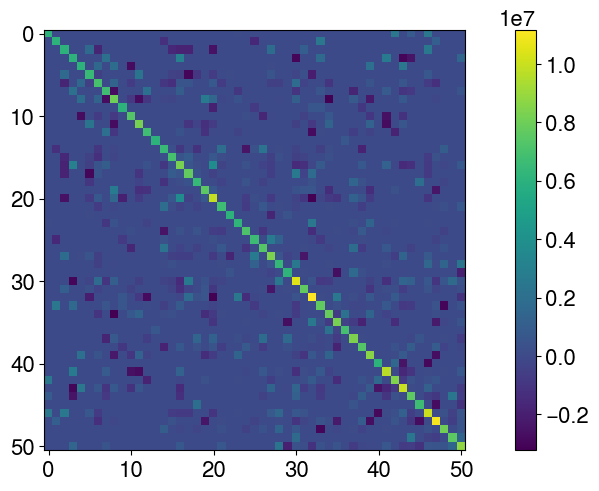

In [7]:
n = np.size(obs)
amplitude = (np.max(obs) - np.min(obs))

# CASE 1: diagonal covariance matrix (this is the simplest case)
# 10% error on the observations
# cov_obs = covmats.CovViaDiagonal(
#     np.ones(n) * amplitude ** 2
# )

# CASE 2: non diagonal through Cholesky
L = np.zeros((n ,n), dtype=np.float64)
# Add some random non-zero covariances
for i in range(n):
    for j in range(i + 1, n):
        if np.random.rand() < 0.1:  # 10% chance of non-zero covariance
            cov = np.random.uniform(-0.05, 0.05) * amplitude
            L[i, j] = cov
            L[j, i] = cov  # symmetry
# Add non zero diagonal
L.flat[:: n + 1] = amplitude * 0.1
# Make it lower triangular and define the covariance as a cholesky factorization
cov_obs = covmats.CovViaCholesky(np.tril(L))

# Show the dense matrix
plt.imshow(cov_obs.todense())
plt.colorbar()

Perturb the observations to avoid the inverse crime (using the same forward to generate the synthetic data and perform the inversion makes the problem well posed and simple to solve. Adding noise mitigates it a bit).

(787.3191490867721, 35303.22862408591)

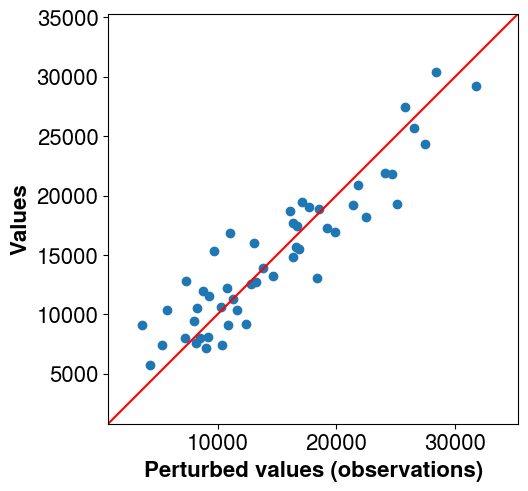

In [8]:
obs_perturb = (
    obs + cov_obs.sample_mvnormal([1], random_state=np.random.default_rng(2151))[0]
)
# Plot the non perturbed observations vs perturbed one
# The perturbed ones will be used for the inversion
pl = ngp.Plotter()
lims = (np.min(obs), np.max(obs))
diff = lims[1] - lims[0]
lims = (lims[0]- 0.2 * diff, lims[1]+ 0.2 * diff)
pl.axes[0].plot(lims, lims, color="r")
pl.axes[0].scatter(obs_perturb, obs)
pl.axes[0].set_xlabel("Perturbed values (observations)")
pl.axes[0].set_ylabel("Values")
pl.axes[0].set_aspect("equal")
pl.axes[0].set_xlim(lims)
pl.axes[0].set_ylim(lims)

The next step is to factorize the parameters covariance matrix using Eigne decomposition. For this, we rely on `covmats`. The number of principal component is set to 50.

In [9]:
eig_mat = covmats.eigen_factorize_cov_mat(cov_prior, n_pc=50)
assert eig_mat.n_pts == 4225

It is then possible to check the explained variance retained as a function of the number of principal components kept and adjust the number accordingly. The Eigen factorization is a compression of the information. The less principal components kept, the less foward calls needed in PCGA which is critical when dealing with expensive forward models (e.g., when relying on high fidelity reervoir simlations) but the more "smoohting" it introduces (we can see this as loss of details in the inversion).

Text(0, 0.5, 'Cumulative explained variance(%)')

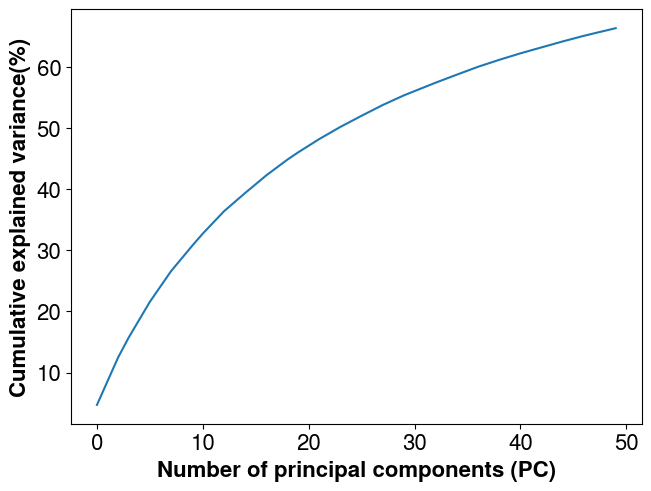

In [10]:
plt.plot(np.cumsum(covmats.get_explained_var(eig_mat.eig_vals, cov_prior)) * 100.0)
plt.xlabel("Number of principal components (PC)")
plt.ylabel("Cumulative explained variance(%)")

- Create the PCGA instance

In [11]:
solver = pypcga.PCGA(
    s_init=s_init.ravel("F"),
    obs=obs_perturb,
    cov_obs=cov_obs,
    forward_model=forward_multiple,
    Q=eig_mat,
    maxiter=5,
    is_lm=True,
    is_direct_solve=False,
    prior_s_var=None,
    random_state=2026,
    max_it_lm=5,
    logger=pcga_logger,
)
# Sanity checks just for the tests
assert solver.s_dim == nx * ny
assert solver.d_dim == obs.size

INFO:PCGA:##### PCGA Inversion #####
INFO:PCGA:##### 1. Initialize forward and inversion parameters
INFO:PCGA:------------ Inversion Parameters -------------------------
INFO:PCGA:  Number of unknowns                    : 4225
INFO:PCGA:  Number of observations                : 51
INFO:PCGA:  Number of principal components (n_pc) : 50
INFO:PCGA:  Maximum Gauss-Newton iterations       : 5
INFO:PCGA:  Machine eps (delta = sqrt(eps))       : 1e-08
INFO:PCGA:  Minimum model change (restol)         : 0.01
INFO:PCGA:  Minimum obj fun change (ftol)         : 0.0
INFO:PCGA:  Target obj fun (ftarget)              : None
INFO:PCGA:  Levenberg-Marquardt (is_lm)           : True
INFO:PCGA:  Minimum LM solution (lm_smin)         : None
INFO:PCGA:  Maximum LM solution (lm_smax)         : None
INFO:PCGA:  Maximum LM iterations (max_it_lm)     : 5
INFO:PCGA:  Line search                           : False
INFO:PCGA:-----------------------------------------------------------


Run the inversion process

In [12]:
s_hat, simul_obs, post_diagv, iter_best = solver.run()

INFO:PCGA:##### 2. Start PCGA Inversion #####
INFO:PCGA:-- evaluate initial solution
INFO:PCGA:** LS objfun 0.5 (obs. diff.)^T R^{-1}(obs. diff.)              : 1.118e+03
INFO:PCGA:** norm LS objfun 0.5 / nobs (obs. diff.)^T R^{-1}(obs. diff.)  : 2.192e+01
INFO:PCGA:** RMSE (norm(obs. diff.)/sqrt(nobs))                           : 1.477e+04
INFO:PCGA:** norm RMSE (norm(obs. diff./sqrtR)/sqrt(nobs))                : 6.622e+00
INFO:PCGA:** objective function (no beta)                                 : 1.132e+03
INFO:PCGA:
INFO:PCGA:***** Iteration 1 ******
INFO:PCGA:computed Jacobian-Matrix products in : 2.193e-02 s
INFO:PCGA:Use Krylov subspace iterative solver for saddle-point (cokrigging) system
INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :3.89e-02 sec
INFO:PCGA:Evaluate the 5 LM solutions
INFO:PCGA:5 objective value evaluations
INFO:PCGA:solution obj=2.83e+03 (cov_obs inflation factor=1.00e+03)
INFO:PCGA:-

Plot the inverted field versus the reference one (inreal world applications, the refrence is not know).

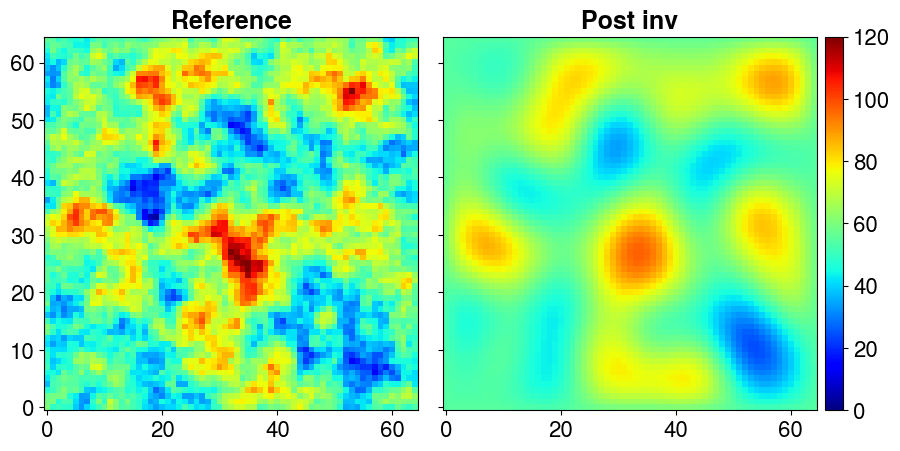

In [13]:
plotter = ngp.Plotter(
    plt.figure(figsize=(9.0, 4.4), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["ref", "inv"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={"Reference": s_ref.T, "Post inv": s_hat.reshape(nx, ny, order="F").T},
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
        vmin=0.0,
        vmax=120,
    ),
    cbar_kwargs=dict(pad=0.01),
)

Le solver retourne une estimation de la variance à posteriori sous la forme d'un vecteur de dimension Ns que nous avons ici stocker dans la variable `post_diagv`. Mais il est également possible d'obtenir une approximation low-rank de la matrice de covariance à posteriori. Le nombre de composante principales ainsi que certains paramètres comme l'inflation peuvent être modifié si nécessaire. Dans le cas présent, nous construsions la matrice avec 25 puis avec 50 composantes principales pour comparer les effets. On construit également la matrice dense (ce qui n'est pas possible pour des problèmes de grande taille) pour comparaison.

In [14]:
post_cov_dense = solver.get_dense_post_cov()
post_cov_25_pc = solver.get_eigen_post_cov(n_pc=25)
post_cov_50_pc = solver.get_eigen_post_cov(n_pc=50)

INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :6.57e-02 sec
INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :4.07e-02 sec
INFO:PCGA:Preconditioner construction using Generalized Eigen-decomposition
INFO:PCGA:Time for data covarance construction :5.49e-02 sec


As previously, the higher the number of PC, the better the approximation of the posterior variance

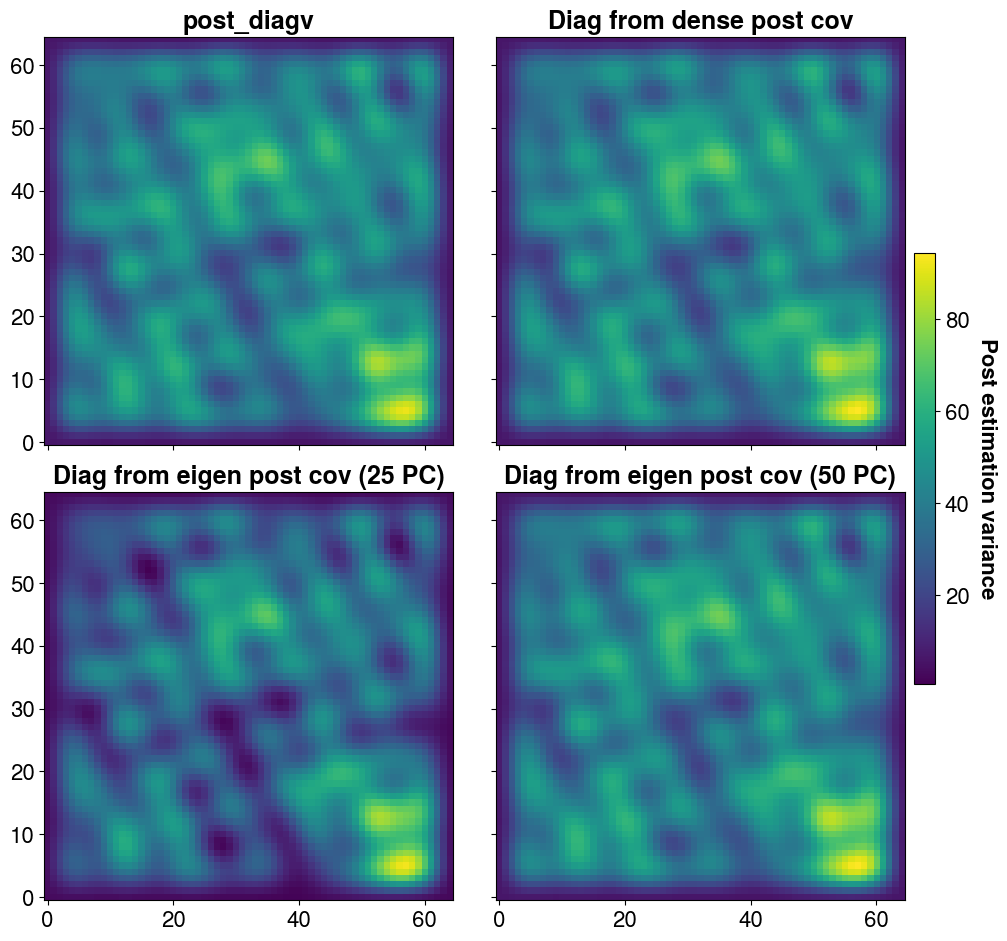

In [15]:
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["diag", "dense"],["25pc", "50pc"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "post_diagv": post_diagv.reshape(nx, ny, order="F").T,
        "Diag from dense post cov": np.diagonal(post_cov_dense).reshape(nx, ny, order="F").T,
        "Diag from eigen post cov (25 PC)": post_cov_25_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
        "Diag from eigen post cov (50 PC)": post_cov_50_pc.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("viridis"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01, shrink=0.5),
    cbar_title="Post estimation variance"
)

The interest of having the posterior covariance matrix (of inversed parameter values) is that it is possible to draw samples (realizations) from it and thus quantify the uncertainty on predictions (at the cost of one forward call per sample)

In [16]:
# make 200 posterior realizations => we sample from post_cov_50_pc and add the results to s_hat, our inversed parameter vector
post_samples = (
    s_hat.T
    + post_cov_50_pc.sample_mvnormal(shape=(200,), random_state=solver.random_state)
).T
post_samples.shape

(4225, 200)

- Let's plot the first 25 realizations

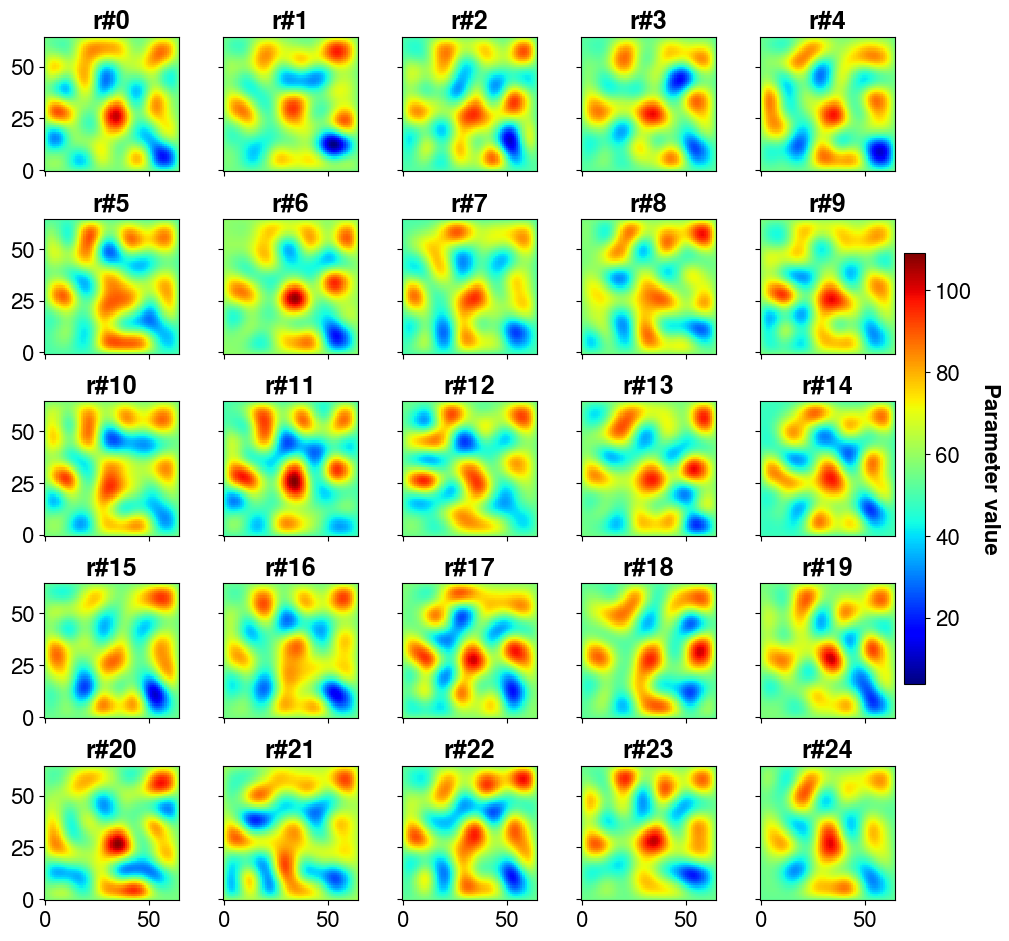

In [17]:
nrows = 5
ncols = 5
plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 9.3), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder(
        [[f"ax{i}-{j}" for i in range(nrows)] for j in range(ncols)],
        sharex=True,
        sharey=True,
    ),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        f"r#{i}": post_samples[:, i].reshape(nx, ny, order="F").T
        for i in range(nrows * ncols)
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("jet"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01, shrink=0.5),
    cbar_title="Parameter value",
)

It is possible to find the variance back from the ensemble

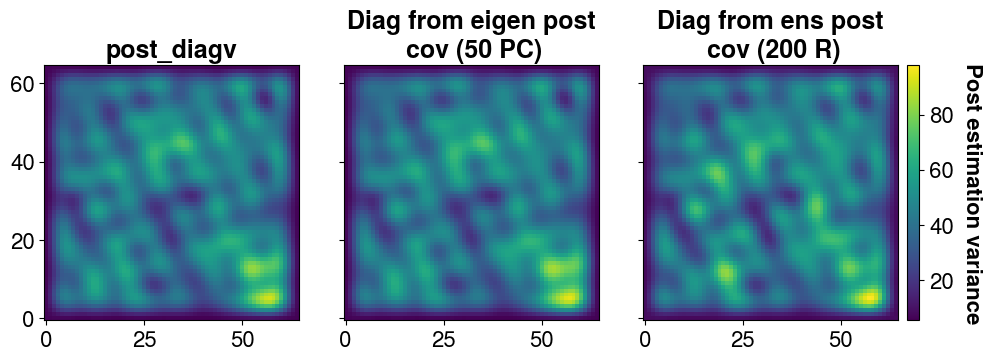

In [26]:
# Covariance from the ensemble
post_cov_ens = covmats.CovViaEnsemble(post_samples.T)

plotter = ngp.Plotter(
    plt.figure(figsize=(10.0, 3.5), constrained_layout=True),
    builder=ngp.SubplotsMosaicBuilder([["diag", "50pc", "ens"]]),
)

ngp.multi_imshow(
    plotter.axes,
    data={
        "post_diagv": post_diagv.reshape(nx, ny, order="F").T,
        "Diag from eigen post\n cov (50 PC)": post_cov_50_pc.get_diagonal()
        .reshape(nx, ny, order="F").T,
        "Diag from ens post\n cov (200 R)": post_cov_ens.get_diagonal()
        .reshape(nx, ny, order="F")
        .T,
    },
    fig=plotter.fig,
    imshow_kwargs=dict(
        origin="lower",
        cmap=plt.get_cmap("viridis"),
        aspect="equal",
    ),
    cbar_kwargs=dict(pad=0.01),
    cbar_title="Post estimation variance"
)